In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

Path to dataset files: /Users/diegoolguin/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2


## Brain Tumor Segmentation in MRI (Lecture Notebook)

This notebook is designed for teaching core ideas in **medical image segmentation** using the LGG MRI dataset.

### Learning goals
1. Understand how slice-level tumor masks are paired with MRI images.
2. Build a simple baseline (Otsu thresholding) and discuss why it fails clinically.
3. Train a compact U-Net for supervised segmentation.
4. Interpret Dice/IoU at slice level and patient level.
5. Discuss limitations, bias, and safe clinical interpretation.

### Important note
This is an **educational prototype** and not a clinical-grade device. Outputs must not be used for diagnosis or treatment decisions.

### Dataset and Clinical Context

- **Dataset**: LGG brain MRI slices with manual tumor masks.
- **Task**: binary segmentation (tumor vs. non-tumor tissue).
- **Clinical relevance**: segmentation can support volumetry, progression tracking, and radiotherapy planning.

In this lecture, treat the notebook as a controlled experiment in model behavior, not as a validated medical product.

In [19]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def otsu_threshold(image: np.ndarray) -> float:
    """Compute Otsu threshold for a [0, 1] grayscale image."""
    hist, _ = np.histogram(image, bins=256, range=(0.0, 1.0))
    hist = hist.astype(np.float64)
    prob = hist / hist.sum()

    omega = np.cumsum(prob)
    bins = np.arange(256)
    mu = np.cumsum(prob * bins)
    mu_t = mu[-1]

    sigma_b2 = (mu_t * omega - mu) ** 2 / np.clip(omega * (1.0 - omega), 1e-12, None)
    best_idx = int(np.argmax(sigma_b2))
    return best_idx / 255.0


def find_image_mask_pairs(root_dir: str):
    """Return list of (image_path, mask_path) pairs based on *_mask naming."""
    mask_paths = glob.glob(os.path.join(root_dir, "**", "*_mask.*"), recursive=True)
    pairs = []

    for mask_path in mask_paths:
        base, ext = os.path.splitext(mask_path)
        image_path = base.replace("_mask", "") + ext
        if os.path.exists(image_path):
            pairs.append((image_path, mask_path))

    return sorted(pairs)


pairs = find_image_mask_pairs(path)
print(f"Found {len(pairs)} image/mask pairs")
if not pairs:
    raise RuntimeError("No image/mask pairs were found. Check dataset download path.")

Found 7858 image/mask pairs


Image: /Users/diegoolguin/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2/kaggle_3m/TCGA_DU_8164_19970111/TCGA_DU_8164_19970111_4.tif
Mask : /Users/diegoolguin/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2/kaggle_3m/TCGA_DU_8164_19970111/TCGA_DU_8164_19970111_4_mask.tif
Otsu threshold: 0.1176
IoU:  0.0000
Dice: 0.0000


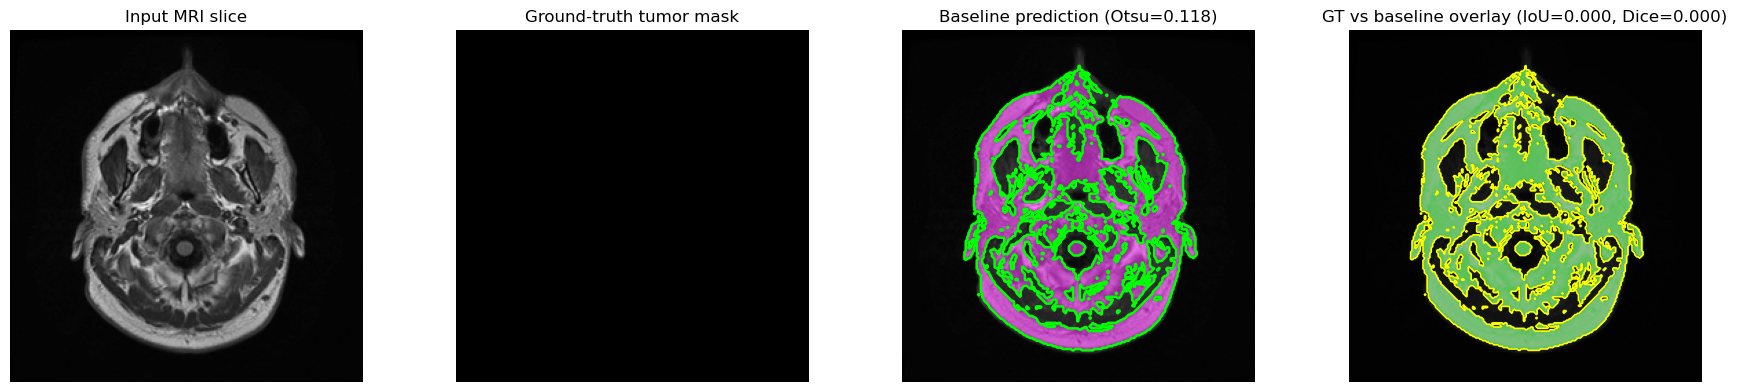

In [20]:
# Pick a random sample pair
image_path, mask_path = random.choice(pairs)
print("Image:", image_path)
print("Mask :", mask_path)

# Load as grayscale arrays in [0, 1]
image = np.array(Image.open(image_path).convert("L"), dtype=np.float32) / 255.0
mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)
gt = mask > 0  # Ground-truth binary mask

# Baseline segmentation using Otsu thresholding
thr = otsu_threshold(image)
pred = image > thr

# Metrics
iou = np.logical_and(pred, gt).sum() / np.logical_or(pred, gt).sum()
dice = (2 * np.logical_and(pred, gt).sum()) / (pred.sum() + gt.sum())

print(f"Otsu threshold: {thr:.4f}")
print(f"IoU:  {iou:.4f}")
print(f"Dice: {dice:.4f}")

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Input MRI slice")
axes[0].axis("off")

axes[1].imshow(gt, cmap="gray")
axes[1].set_title("Ground-truth tumor mask")
axes[1].axis("off")

axes[2].imshow(image, cmap="gray")
axes[2].imshow(np.ma.masked_where(~pred, pred), cmap="spring", alpha=0.45)
axes[2].contour(pred.astype(np.uint8), levels=[0.5], colors="lime", linewidths=1.8)
axes[2].set_title(f"Baseline prediction (Otsu={thr:.3f})")
axes[2].axis("off")

overlay = np.stack([image, image, image], axis=-1)
overlay[..., 0] = np.where(gt, 1.0, overlay[..., 0])
overlay[..., 1] = np.where(pred, 1.0, overlay[..., 1])
axes[3].imshow(overlay)
axes[3].imshow(np.ma.masked_where(~pred, pred), cmap="spring", alpha=0.25)
axes[3].contour(pred.astype(np.uint8), levels=[0.5], colors="yellow", linewidths=1.2)
axes[3].set_title(f"GT vs baseline overlay (IoU={iou:.3f}, Dice={dice:.3f})")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## Supervised U-Net for Tumor Delineation

In this section we train a compact residual U-Net to segment tumor regions from grayscale MRI slices.

### Medical framing
- **Input:** a 2D MRI slice.
- **Output:** a pixel-wise tumor probability map.
- **Clinical analogy:** semi-automatic contour support for lesion delineation (educational only).

### Teaching focus
We emphasize architecture design, class imbalance handling, and clinically interpretable validation (slice-level and patient-level).

### Training Strategy and Why It Matters Clinically

#### 1) Loss design (with formulas)
The training objective combines weighted BCE and Focal-Tversky:

$$
\mathcal{L}_{\text{total}} = \lambda_{\text{BCE}}\,\mathcal{L}_{\text{BCE}} + \lambda_{\text{FT}}\,\mathcal{L}_{\text{Focal-Tversky}}
$$

where in this notebook $\lambda_{\text{BCE}}=0.3$ and $\lambda_{\text{FT}}=0.7$.

Weighted BCE (using logits $z$ and target $y\in\{0,1\}$):

$$
\mathcal{L}_{\text{BCE}} = -\frac{1}{N}\sum_i\Big[w_{+}\,y_i\log\sigma(z_i) + (1-y_i)\log(1-\sigma(z_i))\Big]
$$

Tversky index:

$$
\text{TI} = \frac{TP + \varepsilon}{TP + \alpha\,FP + \beta\,FN + \varepsilon}
$$

Focal-Tversky loss:

$$
\mathcal{L}_{\text{Focal-Tversky}} = (1-\text{TI})^{\gamma}
$$

with $\alpha=0.7$, $\beta=0.3$, and $\gamma=1.33$ in this implementation.

**Clinical intuition:** this configuration penalizes false negatives more strongly, which is useful when missing tumor tissue is costly.

#### 2) Sampling strategy
- `WeightedRandomSampler` oversamples tumor-containing slices.
- This reduces domination by easy background-only examples and improves lesion-focused learning.

#### 3) EMA (Exponential Moving Average)
EMA keeps a smoothed copy of model weights:

$$
\theta^{\text{EMA}}_t = d\,\theta^{\text{EMA}}_{t-1} + (1-d)\,\theta_t
$$

where $d$ is the decay (here, $d=0.995$), $\theta_t$ are current model weights, and $\theta^{\text{EMA}}_t$ are smoothed weights.

**Why this helps:** EMA filters high-frequency optimizer noise, often yielding more stable validation behavior and better generalization.

#### 4) TTA (Test-Time Augmentation) — expanded view
At inference, we predict on transformed versions of the same image (here: identity, horizontal flip, vertical flip, and both flips), invert each transform back to original orientation, then average probabilities.

If $T_k$ is a flip transform and $T_k^{-1}$ its inverse, then:

$$
\hat{p}(x)=\frac{1}{K}\sum_{k=1}^{K} T_k^{-1}\Big( f\big(T_k(x)\big) \Big)
$$

where $f(\cdot)$ outputs probability maps and $K=4$ in this notebook.

Final binary mask is obtained by thresholding:

$$
\hat{y}=\mathbb{1}[\hat{p}(x)>\tau]
$$

**Practical effect:** TTA reduces prediction variance from orientation sensitivity and typically produces smoother, more robust tumor contours.

#### 5) Early stopping
- Stops training when validation loss no longer improves by a minimum margin.
- This helps prevent overfitting and supports more reproducible teaching demos.

### Symbol Glossary (Detailed)

This glossary explains every symbol used in the formulas above, with practical interpretation for this notebook.

#### Core data and prediction symbols
- $x$: input MRI slice (a 2D grayscale image).
- $y$: ground-truth mask (binary target map, tumor vs background).
- $y_i$: target value at pixel $i$ (typically $1$ for tumor, $0$ for non-tumor).
- $\hat{y}$: final binary prediction after thresholding.
- $z_i$: model output **logit** at pixel $i$ (before sigmoid).
- $\sigma(z_i)$: predicted probability at pixel $i$ after sigmoid.
- $\hat{p}(x)$: averaged probability map after TTA.

#### Loss-combination symbols
- $\mathcal{L}_{\text{total}}$: total objective minimized during training.
- $\mathcal{L}_{\text{BCE}}$: weighted binary cross-entropy term.
- $\mathcal{L}_{\text{Focal-Tversky}}$: focal-Tversky term.
- $\lambda_{\text{BCE}}$: contribution weight of BCE in the final loss.
- $\lambda_{\text{FT}}$: contribution weight of focal-Tversky in the final loss.

In this notebook, the practical rule is:
- BCE helps with probabilistic calibration under imbalance.
- Focal-Tversky pushes overlap quality and FN-sensitive learning.

#### Pixel-count and weighting symbols
- $N$: number of pixels (or effective elements) used in averaging.
- $w_+$: positive-class weight in BCE (upweights tumor pixels).

Why it matters:
- Tumor pixels are sparse; without weighting, gradients are dominated by background.

#### Overlap statistics symbols
- $TP$: true positives (tumor predicted as tumor).
- $FP$: false positives (background predicted as tumor).
- $FN$: false negatives (tumor predicted as background).

Clinical interpretation:
- High $FN$ can be riskier in many tumor-delineation contexts because lesions may be missed.

#### Tversky/Focal parameters
- $\alpha$: penalty coefficient for false positives in Tversky.
- $\beta$: penalty coefficient for false negatives in Tversky.
- $\gamma$: focal exponent; increases focus on difficult cases.
- $\varepsilon$: tiny numerical constant to avoid divide-by-zero instability.

Notebook setting and implication:
- With $\alpha=0.7$ and $\beta=0.3$, the index is asymmetric.
- With focal exponent $\gamma>1$, harder examples contribute relatively more.

#### EMA symbols
- $\theta_t$: raw model weights after optimizer step $t$.
- $\theta_t^{\text{EMA}}$: smoothed EMA weights at step $t$.
- $d$: EMA decay factor (closer to $1$ means stronger smoothing).

Interpretation in class terms:
- EMA acts like a temporal low-pass filter over parameters.
- It reduces sensitivity to noisy minibatch updates.

#### TTA symbols
- $T_k$: transform index $k$ (identity/flip transforms in this notebook).
- $T_k^{-1}$: inverse transform used to map predictions back to original orientation.
- $f(\cdot)$: model inference function that returns a probability map.
- $K$: number of TTA views used in averaging.
- $\tau$: threshold applied to $\hat{p}(x)$ for binary mask extraction.
- $\mathbb{1}[\cdot]$: indicator function (returns $1$ when condition is true, else $0$).

Practical reading of the TTA formula:
1. Transform image.
2. Predict.
3. Undo transform on prediction.
4. Average all aligned predictions.
5. Threshold to produce final segmentation.

---

### Quick mapping to your code
- $\lambda_{\text{BCE}}, \lambda_{\text{FT}}$ correspond to `BCE_WEIGHT` and `FOCAL_TVERSKY_WEIGHT`.
- $\alpha, \beta, \gamma$ correspond to `TVERSKY_ALPHA`, `TVERSKY_BETA`, `FOCAL_GAMMA`.
- $d$ corresponds to `EMA_DECAY`.
- $\tau$ is the selected threshold from your validation threshold search.

### U-Net Architecture Deep Dive

This notebook uses a **Residual SE U-Net** (`SmallUNet`) rather than a plain U-Net.

#### Encoder-decoder structure
- The **encoder path** progressively downsamples the image to capture contextual and anatomical information.
- The **decoder path** upsamples feature maps to recover spatial detail.
- **Skip connections** concatenate encoder features with decoder features at matching scales.

#### Why residual blocks?
- Residual connections stabilize optimization in deeper networks.
- They improve gradient flow and typically reduce underfitting in small medical datasets.

#### Why SE (Squeeze-and-Excitation) blocks?
- SE blocks reweight feature channels based on global context.
- In MRI segmentation, this helps emphasize subtle tumor-related signal while suppressing background channels.

#### Output interpretation
- The final 1-channel head produces **logits**.
- Applying sigmoid converts logits to probabilities in `[0, 1]`.
- A threshold (tuned on validation) converts probabilities to a binary mask.

### Architecture Diagram (Channel Flow)

```text
Input MRI slice (1 x 128 x 128)
        |
        v
Encoder:
  E1: ResidualSEBlock(1   -> 48)      -> 48 x 128 x 128
  MaxPool
  E2: ResidualSEBlock(48  -> 96)      -> 96 x 64 x 64
  MaxPool
  E3: ResidualSEBlock(96  -> 192)     -> 192 x 32 x 32
  MaxPool
  E4: ResidualSEBlock(192 -> 384)     -> 384 x 16 x 16
  MaxPool

Bottleneck:
  ResidualSEBlock(384 -> 768)         -> 768 x 8 x 8

Decoder:
  UpConv(768 -> 384), concat(E4)      -> (384 + 384) x 16 x 16
  D4: ResidualSEBlock(768 -> 384)

  UpConv(384 -> 192), concat(E3)      -> (192 + 192) x 32 x 32
  D3: ResidualSEBlock(384 -> 192)

  UpConv(192 -> 96), concat(E2)       -> (96 + 96) x 64 x 64
  D2: ResidualSEBlock(192 -> 96)

  UpConv(96 -> 48), concat(E1)        -> (48 + 48) x 128 x 128
  D1: ResidualSEBlock(96 -> 48)

Segmentation head:
  Conv1x1(48 -> 1)                    -> logits (1 x 128 x 128)
  Sigmoid                             -> probability map
  Threshold                           -> binary tumor mask
```

### Why skip connections matter in MRI
- Deep layers capture context ("where could tumor be?").
- Early layers preserve boundaries ("exactly where is the edge?").
- Concatenating both helps improve delineation of irregular tumor margins.

### Training and Inference Pipeline (Lecture View)

```text
Data source (LGG MRI + masks)
        |
        v
Pair matching (image, mask)
        |
        v
Train/Val split (balanced for non-empty masks)
        |
        +--> Train path ----------------------------------------------+
        |     Augmentations (flip, gamma)                            |
        |     Weighted sampler (foreground-aware)                    |
        |     Forward pass (Residual SE U-Net)                       |
        |     Loss = weighted BCE + Focal-Tversky                    |
        |     Backprop + optimizer step (AdamW)                      |
        |     EMA update (smoothed weights)                          |
        +-------------------------------------------------------------+
        |
        +--> Validation path -----------------------------------------+
              Forward pass (no grad)                                 |
              Loss tracking + early stopping                          |
              Best checkpoint selection (EMA best state)              |
        +-------------------------------------------------------------+
        |
        v
Inference on validation samples
        |
        v
TTA (flip-based averaging) -> probability map -> thresholding
        |
        v
Metrics (IoU, Dice) + patient-level aggregation + failure analysis
```

### Teaching interpretation
- **Why this flow matters:** each stage targets a different risk (imbalance, overfitting, unstable contours, patient variability).
- **Clinical translation:** better overlap metrics are useful, but failure analysis by patient is essential before discussing real-world utility.

In [21]:
import copy
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


# Training config
IMG_SIZE = 128
MAX_TRAIN = 512
MAX_VAL = 96
BATCH_SIZE = 12
EPOCHS = 14
LR = 8e-4

# Fine-tuning knobs
TVERSKY_ALPHA = 0.7
TVERSKY_BETA = 0.3
FOCAL_GAMMA = 1.33
BCE_WEIGHT = 0.3
FOCAL_TVERSKY_WEIGHT = 0.7
EMA_DECAY = 0.995

unet_device = "cuda" if torch.cuda.is_available() else ("mps" if torch.mps.is_available() else "cpu")
print("U-Net device:", unet_device)


class MRISegmentationDataset(Dataset):
    def __init__(self, pair_list, image_size=128, augment=False):
        self.pairs = pair_list
        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_p, mask_p = self.pairs[idx]
        image = Image.open(img_p).convert("L").resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = Image.open(mask_p).convert("L").resize((self.image_size, self.image_size), Image.NEAREST)

        image = np.array(image, dtype=np.float32) / 255.0
        mask = (np.array(mask, dtype=np.uint8) > 0).astype(np.float32)

        if self.augment:
            if random.random() < 0.5:
                image = np.fliplr(image).copy()
                mask = np.fliplr(mask).copy()
            if random.random() < 0.5:
                image = np.flipud(image).copy()
                mask = np.flipud(mask).copy()
            if random.random() < 0.25:
                gamma = random.uniform(0.8, 1.2)
                image = np.clip(image ** gamma, 0.0, 1.0)

        image = torch.from_numpy(image).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)
        return image, mask


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        scale = self.fc(self.pool(x))
        return x * scale


class ResidualSEBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.se = SEBlock(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

        if in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.drop(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.se(out)
        out = out + identity
        out = self.relu(out)
        return out


class SmallUNet(nn.Module):
    """A more powerful U-Net backbone using residual + SE blocks."""

    def __init__(self, base_ch=48):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        self.enc1 = ResidualSEBlock(1, base_ch, dropout=0.0)
        self.enc2 = ResidualSEBlock(base_ch, base_ch * 2, dropout=0.05)
        self.enc3 = ResidualSEBlock(base_ch * 2, base_ch * 4, dropout=0.1)
        self.enc4 = ResidualSEBlock(base_ch * 4, base_ch * 8, dropout=0.15)

        self.bottleneck = ResidualSEBlock(base_ch * 8, base_ch * 16, dropout=0.2)

        self.up4 = nn.ConvTranspose2d(base_ch * 16, base_ch * 8, kernel_size=2, stride=2)
        self.dec4 = ResidualSEBlock(base_ch * 16, base_ch * 8, dropout=0.1)

        self.up3 = nn.ConvTranspose2d(base_ch * 8, base_ch * 4, kernel_size=2, stride=2)
        self.dec3 = ResidualSEBlock(base_ch * 8, base_ch * 4, dropout=0.1)

        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = ResidualSEBlock(base_ch * 4, base_ch * 2, dropout=0.05)

        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = ResidualSEBlock(base_ch * 2, base_ch, dropout=0.0)

        self.head = nn.Conv2d(base_ch, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.head(d1)


def dice_loss_from_logits(logits, target, eps=1e-6):
    probs = torch.sigmoid(logits)
    inter = (probs * target).sum(dim=(1, 2, 3))
    denom = probs.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2.0 * inter + eps) / (denom + eps)
    return 1.0 - dice.mean()


def focal_tversky_loss_from_logits(logits, target, alpha=0.7, beta=0.3, gamma=1.33, eps=1e-6):
    probs = torch.sigmoid(logits)
    tp = (probs * target).sum(dim=(1, 2, 3))
    fp = (probs * (1.0 - target)).sum(dim=(1, 2, 3))
    fn = ((1.0 - probs) * target).sum(dim=(1, 2, 3))
    tversky = (tp + eps) / (tp + alpha * fp + beta * fn + eps)
    return ((1.0 - tversky) ** gamma).mean()


def compute_segmentation_loss(logits, target):
    return (
        BCE_WEIGHT * bce(logits, target)
        + FOCAL_TVERSKY_WEIGHT * focal_tversky_loss_from_logits(
            logits,
            target,
            alpha=TVERSKY_ALPHA,
            beta=TVERSKY_BETA,
            gamma=FOCAL_GAMMA,
        )
    )


class ModelEMA:
    def __init__(self, model, decay=0.995):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    def update(self, model):
        for key, value in model.state_dict().items():
            if value.dtype.is_floating_point:
                self.shadow[key].mul_(self.decay).add_(value.detach(), alpha=1.0 - self.decay)
            else:
                self.shadow[key] = value.detach().clone()


def predict_prob_with_tta(model, image_chw, device, use_tta=True):
    x = image_chw.unsqueeze(0).to(device)
    tta_dims = [None, (-1,), (-2,), (-1, -2)] if use_tta else [None]
    probs = []

    with torch.no_grad():
        for dims in tta_dims:
            x_aug = torch.flip(x, dims=dims) if dims is not None else x
            logits = model(x_aug)
            prob = torch.sigmoid(logits)
            if dims is not None:
                prob = torch.flip(prob, dims=dims)
            probs.append(prob)

    mean_prob = torch.stack(probs, dim=0).mean(dim=0)
    return mean_prob[0, 0].cpu().numpy()


def has_foreground(mask_path):
    m = np.array(Image.open(mask_path).convert("L"), dtype=np.uint8)
    return bool((m > 0).any())


# Build a more balanced train/val split
rng = random.Random(42)
pairs_shuffled = pairs.copy()
rng.shuffle(pairs_shuffled)

non_empty_pairs = [p for p in pairs_shuffled if has_foreground(p[1])]
empty_pairs = [p for p in pairs_shuffled if not has_foreground(p[1])]

n_train_non_empty = min(len(non_empty_pairs), int(MAX_TRAIN * 0.75))
n_train_empty = min(len(empty_pairs), MAX_TRAIN - n_train_non_empty)

train_pairs = non_empty_pairs[:n_train_non_empty] + empty_pairs[:n_train_empty]
rng.shuffle(train_pairs)

remaining_non_empty = non_empty_pairs[n_train_non_empty:]
remaining_empty = empty_pairs[n_train_empty:]
val_pairs = (remaining_non_empty[:MAX_VAL] if len(remaining_non_empty) >= MAX_VAL else (remaining_non_empty + remaining_empty[:MAX_VAL - len(remaining_non_empty)]))

print(f"Total pairs: {len(pairs_shuffled)}")
print(f"Non-empty masks: {len(non_empty_pairs)} | Empty masks: {len(empty_pairs)}")
print(f"Train samples: {len(train_pairs)}")
print(f"Val samples:   {len(val_pairs)}")

train_ds = MRISegmentationDataset(train_pairs, image_size=IMG_SIZE, augment=True)
val_ds = MRISegmentationDataset(val_pairs, image_size=IMG_SIZE, augment=False)

# Weighted sampling (oversample foreground slices)
train_is_foreground = [1 if has_foreground(mask_p) else 0 for _, mask_p in train_pairs]
fg_count = max(sum(train_is_foreground), 1)
bg_count = max(len(train_is_foreground) - fg_count, 1)
fg_weight = 0.5 / fg_count
bg_weight = 0.5 / bg_count
sample_weights = [fg_weight if is_fg else bg_weight for is_fg in train_is_foreground]
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# Estimate pixel imbalance for weighted BCE
pos_pixels = 0.0
total_pixels = 0.0
for _, m in train_ds:
    pos_pixels += float(m.sum().item())
    total_pixels += float(m.numel())

neg_pixels = max(total_pixels - pos_pixels, 1.0)
pos_pixels = max(pos_pixels, 1.0)
pos_weight_value = min(20.0, max(1.0, neg_pixels / pos_pixels))
print(f"BCE pos_weight: {pos_weight_value:.2f}")

unet = SmallUNet(base_ch=48).to(unet_device)
optimizer = torch.optim.AdamW(unet.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], device=unet_device))
ema = ModelEMA(unet, decay=EMA_DECAY)

best_state = None
best_val_loss = float("inf")

U-Net device: mps


KeyboardInterrupt: 

In [ ]:
load_model = True  # Set to True to load the best model from disk if available

checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "unet_resse_best.pt")

loaded_checkpoint = {"threshold": 0.5}

if load_model and os.path.exists(checkpoint_path):
    print("Loading best model checkpoint from disk...")
    checkpoint = torch.load(checkpoint_path, map_location=unet_device)
    unet.load_state_dict(checkpoint["model_state_dict"])
    if "ema_state_dict" in checkpoint and "ema" in globals():
        ema.shadow = {k: v.clone() for k, v in checkpoint["ema_state_dict"].items()}
    best_val_loss = checkpoint.get("best_val_loss", best_val_loss)
    print(f"Loaded checkpoint with validation loss: {best_val_loss:.4f}")
    loaded_checkpoint = {
        "model_state_dict": checkpoint["model_state_dict"],
        "best_val_loss": best_val_loss,
        "threshold": checkpoint.get("threshold", 0.5),
    }

print("Checkpoint loaded successfully.")
print(f"Loaded threshold: {loaded_checkpoint.get('threshold', 0.5):.2f}")

Loading best model checkpoint from disk...
Loaded checkpoint with validation loss: 0.2679
Checkpoint loaded successfully.
Loaded threshold: 0.65


In [ ]:
EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
MIN_IMPROVEMENT = 1e-4

epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    try:
        unet.train()
        train_loss = 0.0

        for images_batch, masks_batch in train_loader:
            images_batch = images_batch.to(unet_device)
            masks_batch = masks_batch.to(unet_device)

            optimizer.zero_grad()
            logits = unet(images_batch)
            loss = compute_segmentation_loss(logits, masks_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)
            optimizer.step()
            ema.update(unet)

            train_loss += loss.item() * images_batch.size(0)

        train_loss /= max(len(train_ds), 1)

        unet.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images_batch, masks_batch in val_loader:
                images_batch = images_batch.to(unet_device)
                masks_batch = masks_batch.to(unet_device)
                logits = unet(images_batch)
                loss = compute_segmentation_loss(logits, masks_batch)
                val_loss += loss.item() * images_batch.size(0)

        val_loss /= max(len(val_ds), 1)
        scheduler.step()

        if val_loss < (best_val_loss - MIN_IMPROVEMENT):
            best_val_loss = val_loss
            best_state = copy.deepcopy(ema.shadow)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch}/{EPOCHS} - train_loss: {train_loss:.4f} - "
            f"val_loss: {val_loss:.4f} - lr: {scheduler.get_last_lr()[0]:.6f} - "
            f"no_improve: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
        )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping at epoch {epoch}: no val improvement > {MIN_IMPROVEMENT} "
                f"for {EARLY_STOPPING_PATIENCE} consecutive epochs."
            )
            break
    except Exception as e:
        if e is KeyboardInterrupt:
            print("Training interrupted by user.")
        else:
            print(f"Error during training at epoch {epoch}: {e}")
        break

if best_state is not None:
    unet.load_state_dict(best_state)
    print(f"Loaded best EMA model weights from val_loss={best_val_loss:.4f}")

Epoch 1/20 - train_loss: 0.5334 - val_loss: 0.3701 - lr: 0.000790 - no_improve: 1/5
Epoch 2/20 - train_loss: 0.5442 - val_loss: 0.3469 - lr: 0.000760 - no_improve: 2/5
Epoch 3/20 - train_loss: 0.5312 - val_loss: 0.3967 - lr: 0.000713 - no_improve: 3/5
Epoch 4/20 - train_loss: 0.5332 - val_loss: 0.3355 - lr: 0.000649 - no_improve: 4/5
Epoch 5/20 - train_loss: 0.5276 - val_loss: 0.2956 - lr: 0.000574 - no_improve: 5/5
Early stopping at epoch 5: no val improvement > 0.0001 for 5 consecutive epochs.


Validation index: 31
Selected threshold: 0.35
U-Net IoU:  0.1991
U-Net Dice: 0.3320


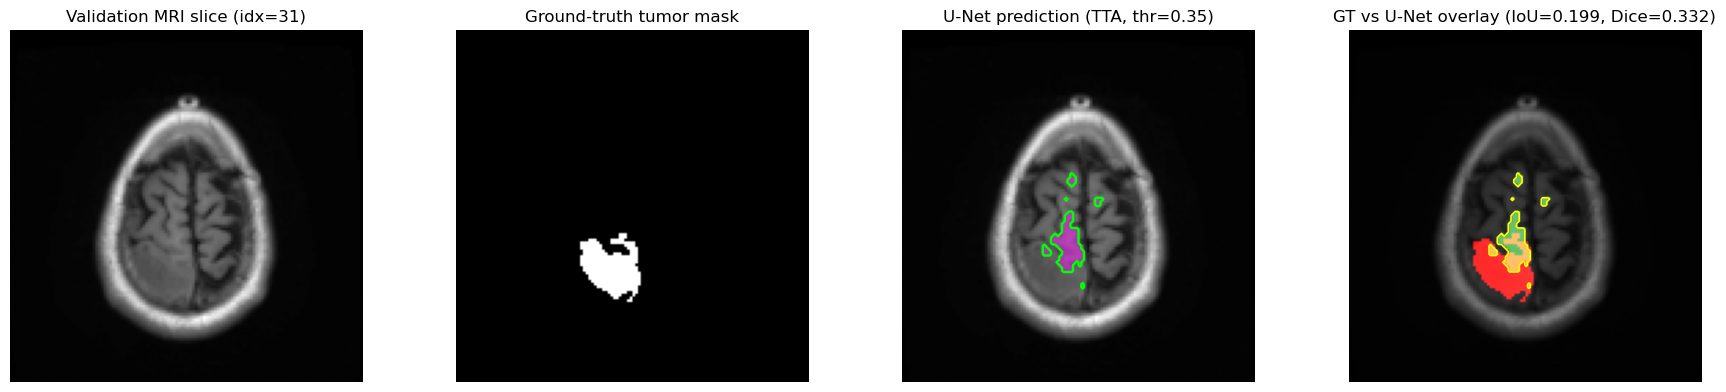

In [ ]:
# Evaluate one non-empty validation sample (with TTA)
unet.eval()

non_empty_val_indices = []
for idx, (_, mask_p) in enumerate(val_pairs):
    if has_foreground(mask_p):
        non_empty_val_indices.append(idx)

if non_empty_val_indices:
    ind_val = random.choice(non_empty_val_indices)
else:
    ind_val = random.randint(0, len(val_ds) - 1)

image_val, mask_val = val_ds[ind_val]

prob_val = predict_prob_with_tta(unet, image_val, unet_device, use_tta=True)

# Tune threshold on this sample among a small set
threshold_candidates = [0.35, 0.4, 0.45, 0.5, 0.55]
gt_unet = mask_val[0].numpy() > 0.5
best_thresh = 0.5
best_dice = -1.0
best_pred = None

for t in threshold_candidates:
    pred_t = prob_val > t
    dice_t = (2 * np.logical_and(pred_t, gt_unet).sum()) / np.clip(pred_t.sum() + gt_unet.sum(), 1, None)
    if dice_t > best_dice:
        best_dice = dice_t
        best_thresh = t
        best_pred = pred_t

pred_unet = best_pred
image_unet = image_val[0].numpy()

iou_unet = np.logical_and(pred_unet, gt_unet).sum() / np.clip(np.logical_or(pred_unet, gt_unet).sum(), 1, None)
dice_unet = (2 * np.logical_and(pred_unet, gt_unet).sum()) / np.clip(pred_unet.sum() + gt_unet.sum(), 1, None)

print(f"Validation index: {ind_val}")
print(f"Selected threshold: {best_thresh:.2f}")
print(f"U-Net IoU:  {iou_unet:.4f}")
print(f"U-Net Dice: {dice_unet:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(image_unet, cmap="gray")
axes[0].set_title(f"Validation MRI slice (idx={ind_val})")
axes[0].axis("off")

axes[1].imshow(gt_unet, cmap="gray")
axes[1].set_title("Ground-truth tumor mask")
axes[1].axis("off")

axes[2].imshow(image_unet, cmap="gray")
axes[2].imshow(np.ma.masked_where(~pred_unet, pred_unet), cmap="spring", alpha=0.45)
axes[2].contour(pred_unet.astype(np.uint8), levels=[0.5], colors="lime", linewidths=1.8)
axes[2].set_title(f"U-Net prediction (TTA, thr={best_thresh:.2f})")
axes[2].axis("off")

overlay_unet = np.stack([image_unet, image_unet, image_unet], axis=-1)
overlay_unet[..., 0] = np.where(gt_unet, 1.0, overlay_unet[..., 0])
overlay_unet[..., 1] = np.where(pred_unet, 1.0, overlay_unet[..., 1])
axes[3].imshow(overlay_unet)
axes[3].imshow(np.ma.masked_where(~pred_unet, pred_unet), cmap="spring", alpha=0.25)
axes[3].contour(pred_unet.astype(np.uint8), levels=[0.5], colors="yellow", linewidths=1.2)
axes[3].set_title(f"GT vs U-Net overlay (IoU={iou_unet:.3f}, Dice={dice_unet:.3f})")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## Validation Report (Non-Empty Tumor Slices)

This report evaluates segmentation quality on validation slices that contain tumor.

### How to read the metrics
- **IoU**: overlap quality, strict penalty on boundary mismatch.
- **Dice**: overlap quality, commonly used in medical segmentation.
- Mean/median/std help detect instability and outlier behavior.

High average metrics alone are insufficient; distribution tails matter for patient safety.

Validation samples (non-empty): 96
Best global threshold: 0.55
---
Mean IoU:   0.5666
Median IoU: 0.6373
Std IoU:    0.2416
---
Mean Dice:   0.6869
Median Dice: 0.7785
Std Dice:    0.2405
---
Dice >= 0.50: 79.2%
Dice >= 0.70: 59.4%


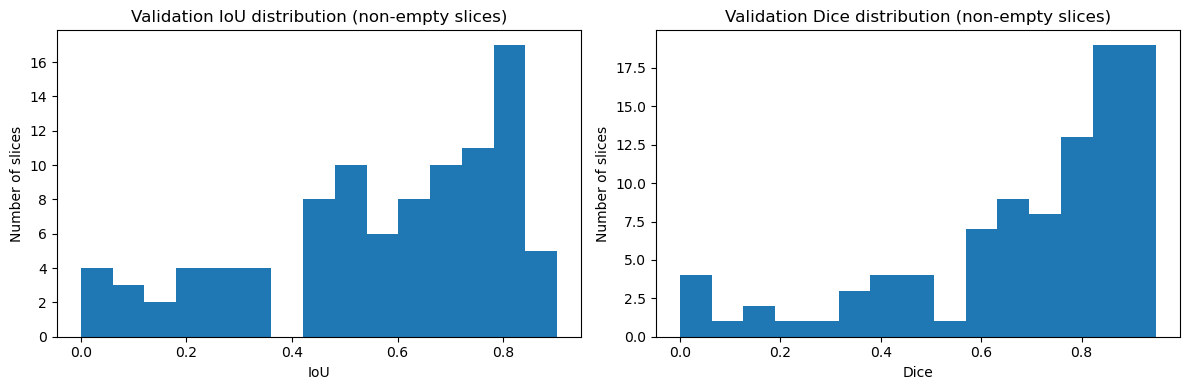

In [ ]:
# Full validation report (non-empty masks, with TTA)
unet.eval()

report_indices = [i for i, (_, mask_p) in enumerate(val_pairs) if has_foreground(mask_p)]
if not report_indices:
    raise RuntimeError("No non-empty validation masks found.")

threshold_grid = np.arange(0.30, 0.71, 0.05)

def compute_metrics_for_threshold(threshold):
    ious = []
    dices = []
    for idx in report_indices:
        image_val, mask_val = val_ds[idx]
        prob_val = predict_prob_with_tta(unet, image_val, unet_device, use_tta=True)

        pred = prob_val > threshold
        gt = mask_val[0].numpy() > 0.5

        iou = np.logical_and(pred, gt).sum() / np.clip(np.logical_or(pred, gt).sum(), 1, None)
        dice = (2 * np.logical_and(pred, gt).sum()) / np.clip(pred.sum() + gt.sum(), 1, None)

        ious.append(float(iou))
        dices.append(float(dice))

    return np.array(ious), np.array(dices)

# Pick global threshold with best mean Dice
best_threshold = None
best_mean_dice = -1.0
best_ious = None
best_dices = None

for thr_candidate in threshold_grid:
    ious_c, dices_c = compute_metrics_for_threshold(float(thr_candidate))
    mean_dice_c = float(dices_c.mean())
    if mean_dice_c > best_mean_dice:
        best_mean_dice = mean_dice_c
        best_threshold = float(thr_candidate)
        best_ious = ious_c
        best_dices = dices_c

print(f"Validation samples (non-empty): {len(report_indices)}")
print(f"Best global threshold: {best_threshold:.2f}")
print("---")
print(f"Mean IoU:   {best_ious.mean():.4f}")
print(f"Median IoU: {np.median(best_ious):.4f}")
print(f"Std IoU:    {best_ious.std():.4f}")
print("---")
print(f"Mean Dice:   {best_dices.mean():.4f}")
print(f"Median Dice: {np.median(best_dices):.4f}")
print(f"Std Dice:    {best_dices.std():.4f}")
print("---")
print(f"Dice >= 0.50: {(best_dices >= 0.50).mean() * 100:.1f}%")
print(f"Dice >= 0.70: {(best_dices >= 0.70).mean() * 100:.1f}%")

# Quick distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(best_ious, bins=15)
axes[0].set_title("Validation IoU distribution (non-empty slices)")
axes[0].set_xlabel("IoU")
axes[0].set_ylabel("Number of slices")

axes[1].hist(best_dices, bins=15)
axes[1].set_title("Validation Dice distribution (non-empty slices)")
axes[1].set_xlabel("Dice")
axes[1].set_ylabel("Number of slices")

plt.tight_layout()
plt.show()

## Per-Patient Validation Summary

Clinical use is patient-centric, so we aggregate slice metrics per patient.

### Why this matters
A model can look strong on average slice metrics while underperforming in specific patients.
Patient-level summaries help expose these failure modes and are more clinically meaningful for lecture discussion.

In [ ]:
# Per-patient validation report (non-empty slices only, with TTA)
unet.eval()

# Reuse the globally selected threshold if available
try:
    threshold_for_patient_report = float(best_threshold)
except NameError:
    threshold_for_patient_report = 0.5

patient_to_indices = {}
for idx in report_indices:
    image_path_i, _ = val_pairs[idx]
    patient_id = os.path.basename(os.path.dirname(image_path_i))
    patient_to_indices.setdefault(patient_id, []).append(idx)

patient_rows = []

for patient_id, indices in patient_to_indices.items():
    ious = []
    dices = []
    for idx in indices:
        image_val, mask_val = val_ds[idx]
        prob_val = predict_prob_with_tta(unet, image_val, unet_device, use_tta=True)

        pred = prob_val > threshold_for_patient_report
        gt = mask_val[0].numpy() > 0.5

        iou = np.logical_and(pred, gt).sum() / np.clip(np.logical_or(pred, gt).sum(), 1, None)
        dice = (2 * np.logical_and(pred, gt).sum()) / np.clip(pred.sum() + gt.sum(), 1, None)

        ious.append(float(iou))
        dices.append(float(dice))

    patient_rows.append(
        {
            "patient_id": patient_id,
            "n_slices": len(indices),
            "mean_iou": float(np.mean(ious)),
            "mean_dice": float(np.mean(dices)),
        }
    )

# Sort by performance (high to low)
patient_rows = sorted(patient_rows, key=lambda x: x["mean_dice"], reverse=True)

patient_mean_ious = np.array([r["mean_iou"] for r in patient_rows], dtype=np.float64)
patient_mean_dices = np.array([r["mean_dice"] for r in patient_rows], dtype=np.float64)

print(f"Patients in non-empty validation set: {len(patient_rows)}")
print(f"Threshold used: {threshold_for_patient_report:.2f}")
print("---")
print(f"Patient-mean IoU (macro):   {patient_mean_ious.mean():.4f}")
print(f"Patient-median IoU:         {np.median(patient_mean_ious):.4f}")
print(f"Patient-mean Dice (macro):  {patient_mean_dices.mean():.4f}")
print(f"Patient-median Dice:        {np.median(patient_mean_dices):.4f}")
print("---")
print("Top 5 patients by mean Dice:")
for r in patient_rows[:5]:
    print(f"  {r['patient_id']}: Dice={r['mean_dice']:.4f}, IoU={r['mean_iou']:.4f}, slices={r['n_slices']}")

print("---")
print("Bottom 5 patients by mean Dice:")
for r in patient_rows[-5:]:
    print(f"  {r['patient_id']}: Dice={r['mean_dice']:.4f}, IoU={r['mean_iou']:.4f}, slices={r['n_slices']}")

Patients in non-empty validation set: 61
Threshold used: 0.55
---
Patient-mean IoU (macro):   0.5456
Patient-median IoU:         0.6192
Patient-mean Dice (macro):  0.6680
Patient-median Dice:        0.7632
---
Top 5 patients by mean Dice:
  TCGA_DU_6404_19850629: Dice=0.9345, IoU=0.8774, slices=2
  TCGA_FG_5964_20010511: Dice=0.9084, IoU=0.8321, slices=1
  TCGA_HT_8107_19980708: Dice=0.9078, IoU=0.8311, slices=1
  TCGA_CS_6666_20011109: Dice=0.9004, IoU=0.8189, slices=1
  TCGA_HT_8105_19980826: Dice=0.8953, IoU=0.8104, slices=1
---
Bottom 5 patients by mean Dice:
  TCGA_HT_8114_19981030: Dice=0.1681, IoU=0.0918, slices=1
  TCGA_DU_5871_19941206: Dice=0.1631, IoU=0.0888, slices=1
  TCGA_HT_A61A_20000127: Dice=0.1473, IoU=0.0945, slices=3
  TCGA_DU_7010_19860307: Dice=0.0588, IoU=0.0303, slices=1
  TCGA_FG_6688_20020215: Dice=0.0000, IoU=0.0000, slices=1


## Failure Analysis: Worst-Performing Patients

This section visualizes representative difficult cases.

### Discussion prompts for class
- Is the error driven by weak contrast, small lesion size, or irregular boundaries?
- Does the model under-segment or over-segment?
- Would this error be clinically acceptable for triage vs. treatment planning?

Failure analysis is essential before any real-world deployment.

Worst 3 patients by mean Dice:
  TCGA_FG_6688_20020215: Dice=0.0000, IoU=0.0000, slices=1
  TCGA_DU_7010_19860307: Dice=0.0588, IoU=0.0303, slices=1
  TCGA_HT_A61A_20000127: Dice=0.1473, IoU=0.0945, slices=3


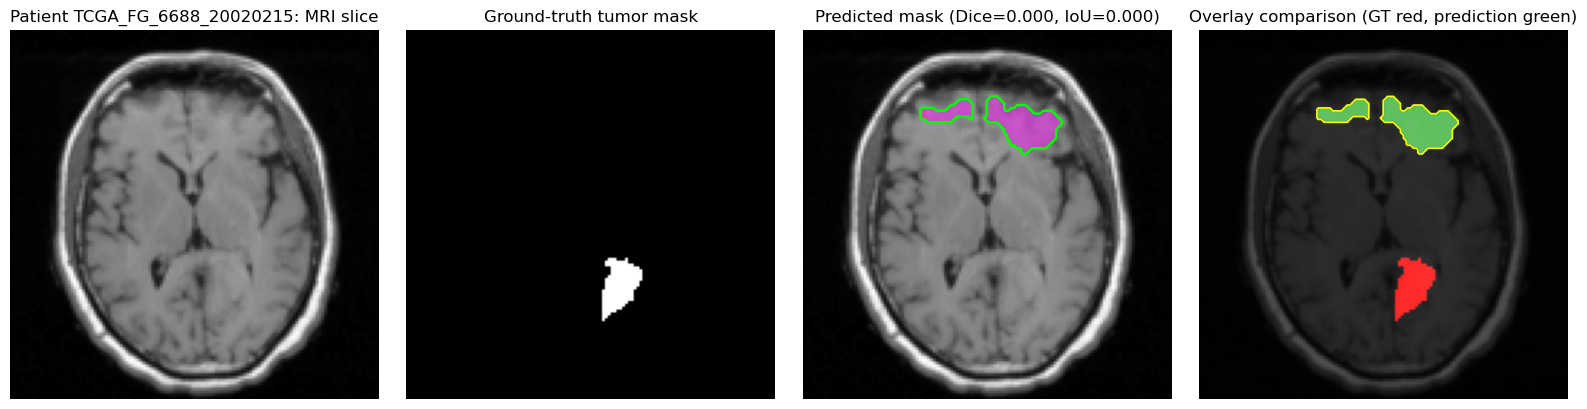

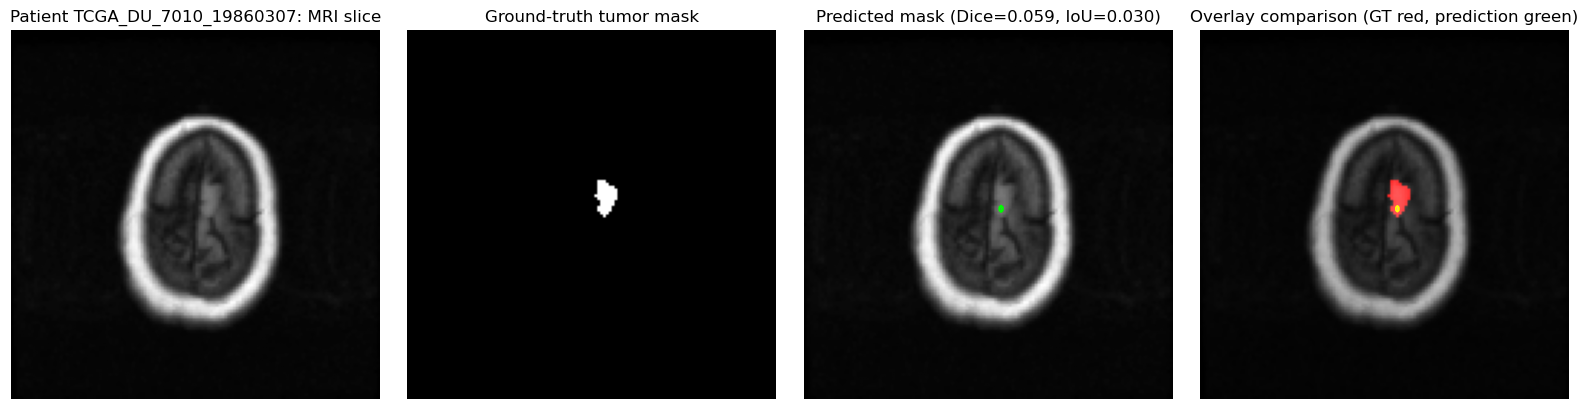

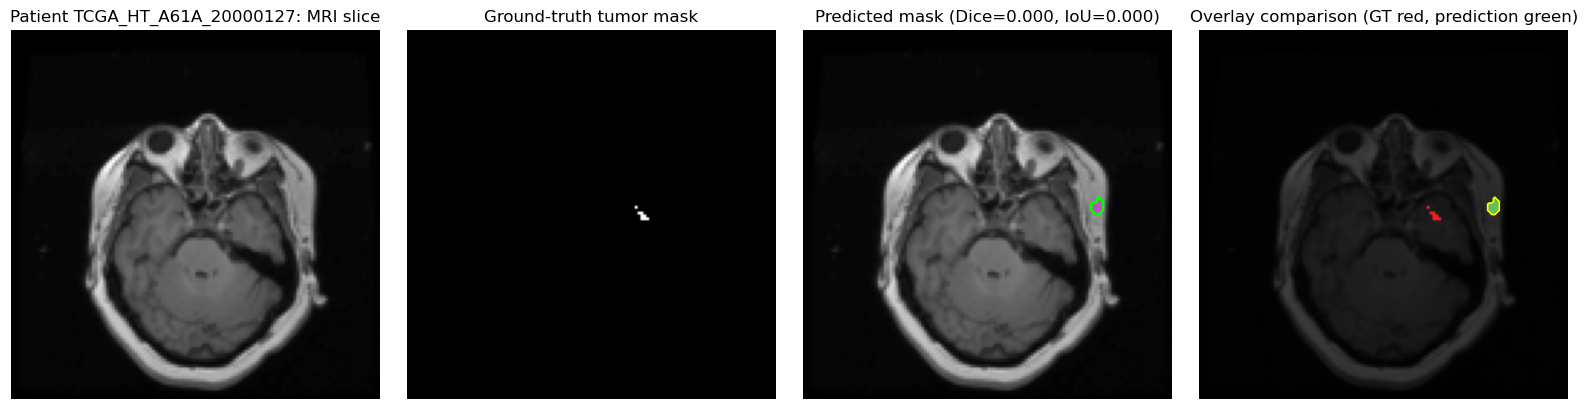

In [ ]:
# Visual diagnostics for 3 worst patients (with TTA)
unet.eval()

if "patient_rows" not in globals() or len(patient_rows) == 0:
    raise RuntimeError("Run the per-patient validation report cell first.")

worst_patients = sorted(patient_rows, key=lambda x: x["mean_dice"])[:3]
print("Worst 3 patients by mean Dice:")
for p in worst_patients:
    print(f"  {p['patient_id']}: Dice={p['mean_dice']:.4f}, IoU={p['mean_iou']:.4f}, slices={p['n_slices']}")

for p in worst_patients:
    pid = p["patient_id"]
    indices = patient_to_indices[pid]

    rep_dice = float("inf")
    rep_iou = 0.0
    rep_image = None
    rep_gt = None
    rep_pred = None

    for idx in indices:
        image_val, mask_val = val_ds[idx]
        prob_val = predict_prob_with_tta(unet, image_val, unet_device, use_tta=True)

        pred = prob_val > threshold_for_patient_report
        gt = mask_val[0].numpy() > 0.5

        iou = np.logical_and(pred, gt).sum() / np.clip(np.logical_or(pred, gt).sum(), 1, None)
        dice = (2 * np.logical_and(pred, gt).sum()) / np.clip(pred.sum() + gt.sum(), 1, None)

        if dice < rep_dice:
            rep_dice = float(dice)
            rep_iou = float(iou)
            rep_image = image_val[0].numpy()
            rep_gt = gt
            rep_pred = pred

    overlay = np.stack([rep_image, rep_image, rep_image], axis=-1)
    overlay[..., 0] = np.where(rep_gt, 1.0, overlay[..., 0])
    overlay[..., 1] = np.where(rep_pred, 1.0, overlay[..., 1])

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(rep_image, cmap="gray")
    axes[0].set_title(f"Patient {pid}: MRI slice")
    axes[0].axis("off")

    axes[1].imshow(rep_gt, cmap="gray")
    axes[1].set_title("Ground-truth tumor mask")
    axes[1].axis("off")

    axes[2].imshow(rep_image, cmap="gray")
    axes[2].imshow(np.ma.masked_where(~rep_pred, rep_pred), cmap="spring", alpha=0.45)
    axes[2].contour(rep_pred.astype(np.uint8), levels=[0.5], colors="lime", linewidths=1.8)
    axes[2].set_title(f"Predicted mask (Dice={rep_dice:.3f}, IoU={rep_iou:.3f})")
    axes[2].axis("off")

    axes[3].imshow(overlay)
    axes[3].imshow(np.ma.masked_where(~rep_pred, rep_pred), cmap="spring", alpha=0.25)
    axes[3].contour(rep_pred.astype(np.uint8), levels=[0.5], colors="yellow", linewidths=1.2)
    axes[3].set_title("Overlay comparison (GT red, prediction green)")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

## Clinical Caveats and Responsible Use

- Ground truth masks may include inter-observer variability.
- Slice-based evaluation ignores full 3D context and temporal progression.
- Metrics do not directly measure clinical outcome impact.
- External validation across scanners/sites is required.

**Take-home message:** good validation metrics are necessary, but not sufficient, for medical deployment.

## Lecture Model Card (One-Slide Summary)

### Model
- **Type:** Residual SE U-Net (2D slice segmentation)
- **Input:** grayscale brain MRI slice (`128 x 128`)
- **Output:** tumor probability map and thresholded binary mask

### Intended educational use
- Demonstrate medical segmentation workflow end-to-end.
- Compare baseline vs deep learning segmentation behavior.
- Teach metric interpretation (Dice/IoU, slice-level and patient-level).

### Not intended for
- Real clinical diagnosis
- Treatment planning
- Autonomous decision-making

### Key strengths in this notebook
- Class-imbalance aware loss and sampling
- EMA stabilization during training
- TTA for more robust inference
- Patient-level and failure-case analysis

### Main limitations
- 2D slice-based approach (limited 3D context)
- Single dataset/domain in this classroom setup
- Limited external validation and calibration analysis
- Potential annotation variability in ground-truth masks

### Safety and ethics note
Any real medical deployment requires multi-center validation, regulatory compliance, clinician oversight, and prospective testing.

In [ ]:
# Save and load model checkpoint
import os
import torch

checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "unet_resse_best.pt")

# Save
checkpoint = {
    "model_state_dict": unet.state_dict(),
    "model_class": "SmallUNet",
    "base_ch": 48,
    "img_size": IMG_SIZE,
    "best_val_loss": float(best_val_loss) if "best_val_loss" in globals() else None,
    "threshold": float(best_threshold) if "best_threshold" in globals() and best_threshold is not None else 0.5,
}
if "ema" in globals():
    checkpoint["ema_state_dict"] = {k: v.detach().cpu() for k, v in ema.shadow.items()}

torch.save(checkpoint, checkpoint_path)
print(f"Checkpoint saved to: {checkpoint_path}")

# Load into a fresh model instance
loaded_checkpoint = torch.load(checkpoint_path, map_location=unet_device)
loaded_unet = SmallUNet(base_ch=loaded_checkpoint.get("base_ch", 48)).to(unet_device)
loaded_unet.load_state_dict(loaded_checkpoint["model_state_dict"])
loaded_unet.eval()

print("Checkpoint loaded successfully.")
print(f"Loaded threshold: {loaded_checkpoint.get('threshold', 0.5):.2f}")

Checkpoint saved to: checkpoints/unet_resse_best.pt
Checkpoint loaded successfully.
Loaded threshold: 0.55


## Improved Model: Attention U-Net with Deep Supervision

### Changes from the baseline `SmallUNet`

| Aspect | Baseline | Improved |
|---|---|---|
| **Skip connections** | Plain concatenation | **Attention Gates** — learnable gating suppresses irrelevant encoder features |
| **Capacity** | `base_ch=48` (~4.7 M params) | `base_ch=64` (~8.5 M params) |
| **Decoder supervision** | Single head | **Deep supervision** — auxiliary 1×1 heads at every decoder scale, upsampled and averaged |
| **Image resolution** | 128×128 | **192×192** — more spatial detail for small tumors |
| **Data augmentation** | Flip + gamma | + **rotation (±15°)**, **Gaussian noise**, **brightness/contrast jitter** |
| **LR schedule** | CosineAnnealing | **OneCycleLR** with warmup |
| **Training budget** | 512 train / 20 epochs | **768 train / 30 epochs** |

### Why these changes help
- **Attention Gates** (Oktay et al., 2018) let the decoder selectively attend to tumour-relevant encoder features, reducing false positives in background regions.
- **Deep supervision** provides gradient signal at multiple resolutions, improving convergence and boundary delineation.
- Higher resolution preserves small-lesion detail that 128 px downsampling can erase.
- Richer augmentation improves generalisation with the small dataset.

In [ ]:
########################################################################
# Improved architecture — Attention U-Net with Deep Supervision
########################################################################

import torch
import torch.nn as nn
import torch.nn.functional as F


# ── Attention Gate ────────────────────────────────────────────────────
class AttentionGate(nn.Module):
    """Additive attention gate (Oktay et al., 2018).
    Learns to suppress irrelevant encoder features before concatenation.
    """

    def __init__(self, F_g, F_l, F_int):
        """
        F_g  : channels from the gating signal (decoder / upsampled)
        F_l  : channels from the skip connection (encoder)
        F_int: intermediate channels (bottleneck)
        """
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(F_int),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(F_int),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        """g: gating signal (coarser), x: encoder skip (finer)."""
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


# ── Residual SE block (reused from baseline) ─────────────────────────
class ResidualSEBlockV2(nn.Module):
    """Conv-BN-ReLU ×2 + SE + residual skip."""

    def __init__(self, in_ch, out_ch, dropout=0.0, reduction=8):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

        hidden = max(out_ch // reduction, 8)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_ch, hidden, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, out_ch, 1),
            nn.Sigmoid(),
        )

        self.relu = nn.ReLU(inplace=True)
        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

        self.skip = (
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch))
            if in_ch != out_ch
            else nn.Identity()
        )

    def forward(self, x):
        identity = self.skip(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        out = out * self.se(out)
        return self.relu(out + identity)


# ── Main model ────────────────────────────────────────────────────────
class AttentionUNet(nn.Module):
    """Attention U-Net with SE residual blocks and deep supervision."""

    def __init__(self, base_ch=64, deep_supervision=True):
        super().__init__()
        self.deep_supervision = deep_supervision
        ch = [base_ch, base_ch * 2, base_ch * 4, base_ch * 8, base_ch * 16]
        # ch = [64, 128, 256, 512, 1024] when base_ch=64
        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.enc1 = ResidualSEBlockV2(1, ch[0], dropout=0.0)
        self.enc2 = ResidualSEBlockV2(ch[0], ch[1], dropout=0.05)
        self.enc3 = ResidualSEBlockV2(ch[1], ch[2], dropout=0.1)
        self.enc4 = ResidualSEBlockV2(ch[2], ch[3], dropout=0.15)

        # Bottleneck
        self.bottleneck = ResidualSEBlockV2(ch[3], ch[4], dropout=0.2)

        # Decoder (upsample → attention gate → concat → conv block)
        self.up4 = nn.ConvTranspose2d(ch[4], ch[3], kernel_size=2, stride=2)
        self.ag4 = AttentionGate(F_g=ch[3], F_l=ch[3], F_int=ch[3] // 2)
        self.dec4 = ResidualSEBlockV2(ch[3] * 2, ch[3], dropout=0.1)

        self.up3 = nn.ConvTranspose2d(ch[3], ch[2], kernel_size=2, stride=2)
        self.ag3 = AttentionGate(F_g=ch[2], F_l=ch[2], F_int=ch[2] // 2)
        self.dec3 = ResidualSEBlockV2(ch[2] * 2, ch[2], dropout=0.1)

        self.up2 = nn.ConvTranspose2d(ch[2], ch[1], kernel_size=2, stride=2)
        self.ag2 = AttentionGate(F_g=ch[1], F_l=ch[1], F_int=ch[1] // 2)
        self.dec2 = ResidualSEBlockV2(ch[1] * 2, ch[1], dropout=0.05)

        self.up1 = nn.ConvTranspose2d(ch[1], ch[0], kernel_size=2, stride=2)
        self.ag1 = AttentionGate(F_g=ch[0], F_l=ch[0], F_int=ch[0] // 2)
        self.dec1 = ResidualSEBlockV2(ch[0] * 2, ch[0], dropout=0.0)

        # Final segmentation head
        self.head = nn.Conv2d(ch[0], 1, kernel_size=1)

        # Auxiliary deep-supervision heads (decoder scales 2–4)
        if deep_supervision:
            self.aux4 = nn.Conv2d(ch[3], 1, kernel_size=1)
            self.aux3 = nn.Conv2d(ch[2], 1, kernel_size=1)
            self.aux2 = nn.Conv2d(ch[1], 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        # Decoder with attention gates
        g4 = self.up4(b)
        e4_att = self.ag4(g4, e4)
        d4 = self.dec4(torch.cat([g4, e4_att], dim=1))

        g3 = self.up3(d4)
        e3_att = self.ag3(g3, e3)
        d3 = self.dec3(torch.cat([g3, e3_att], dim=1))

        g2 = self.up2(d3)
        e2_att = self.ag2(g2, e2)
        d2 = self.dec2(torch.cat([g2, e2_att], dim=1))

        g1 = self.up1(d2)
        e1_att = self.ag1(g1, e1)
        d1 = self.dec1(torch.cat([g1, e1_att], dim=1))

        logits = self.head(d1)

        if self.deep_supervision and self.training:
            target_size = x.shape[2:]
            aux_logits_4 = F.interpolate(self.aux4(d4), size=target_size, mode="bilinear", align_corners=False)
            aux_logits_3 = F.interpolate(self.aux3(d3), size=target_size, mode="bilinear", align_corners=False)
            aux_logits_2 = F.interpolate(self.aux2(d2), size=target_size, mode="bilinear", align_corners=False)
            return logits, aux_logits_4, aux_logits_3, aux_logits_2

        return logits


# Quick sanity check
_dummy = torch.randn(1, 1, 192, 192)
_model = AttentionUNet(base_ch=64, deep_supervision=True)
_model.train()
_out = _model(_dummy)
_n_params = sum(p.numel() for p in _model.parameters())
print(f"AttentionUNet — params: {_n_params / 1e6:.2f} M")
print(f"  Train output shapes: {[o.shape for o in _out]}")
_model.eval()
_out_eval = _model(_dummy)
print(f"  Eval  output shape : {_out_eval.shape}")
del _dummy, _model, _out, _out_eval

In [ ]:
########################################################################
# Improved augmentation dataset + training setup
########################################################################
from scipy.ndimage import rotate as nd_rotate


class MRISegmentationDatasetV2(Dataset):
    """Richer augmentation: flip, rotation, gamma, noise, brightness."""

    def __init__(self, pair_list, image_size=192, augment=False):
        self.pairs = pair_list
        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_p, mask_p = self.pairs[idx]
        image = Image.open(img_p).convert("L").resize(
            (self.image_size, self.image_size), Image.BILINEAR
        )
        mask = Image.open(mask_p).convert("L").resize(
            (self.image_size, self.image_size), Image.NEAREST
        )

        image = np.array(image, dtype=np.float32) / 255.0
        mask = (np.array(mask, dtype=np.uint8) > 0).astype(np.float32)

        if self.augment:
            # Horizontal / vertical flip
            if random.random() < 0.5:
                image = np.fliplr(image).copy()
                mask = np.fliplr(mask).copy()
            if random.random() < 0.5:
                image = np.flipud(image).copy()
                mask = np.flipud(mask).copy()

            # Random rotation ±15 degrees
            if random.random() < 0.4:
                angle = random.uniform(-15, 15)
                image = nd_rotate(image, angle, reshape=False, order=1, mode="nearest")
                mask = nd_rotate(mask, angle, reshape=False, order=0, mode="nearest")
                mask = (mask > 0.5).astype(np.float32)

            # Gamma correction
            if random.random() < 0.3:
                gamma = random.uniform(0.7, 1.4)
                image = np.clip(image ** gamma, 0.0, 1.0)

            # Additive Gaussian noise
            if random.random() < 0.25:
                sigma = random.uniform(0.01, 0.04)
                image = np.clip(image + np.random.normal(0, sigma, image.shape).astype(np.float32), 0.0, 1.0)

            # Brightness / contrast jitter
            if random.random() < 0.25:
                alpha = random.uniform(0.85, 1.15)  # contrast
                beta = random.uniform(-0.08, 0.08)  # brightness
                image = np.clip(alpha * image + beta, 0.0, 1.0)

        image = torch.from_numpy(image).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)
        return image, mask


# ── Config ────────────────────────────────────────────────────────────
V2_IMG_SIZE = 192
V2_MAX_TRAIN = 768
V2_MAX_VAL = 128
V2_BATCH_SIZE = 8      # larger images → smaller batch
V2_EPOCHS = 30
V2_LR = 6e-4

# ── Data split (same strategy, larger budget) ────────────────────────
rng_v2 = random.Random(42)
pairs_v2 = pairs.copy()
rng_v2.shuffle(pairs_v2)

ne_pairs = [p for p in pairs_v2 if has_foreground(p[1])]
em_pairs = [p for p in pairs_v2 if not has_foreground(p[1])]

n_tr_ne = min(len(ne_pairs), int(V2_MAX_TRAIN * 0.75))
n_tr_em = min(len(em_pairs), V2_MAX_TRAIN - n_tr_ne)

v2_train_pairs = ne_pairs[:n_tr_ne] + em_pairs[:n_tr_em]
rng_v2.shuffle(v2_train_pairs)

rem_ne = ne_pairs[n_tr_ne:]
rem_em = em_pairs[n_tr_em:]
v2_val_pairs = (
    rem_ne[:V2_MAX_VAL] if len(rem_ne) >= V2_MAX_VAL
    else rem_ne + rem_em[: V2_MAX_VAL - len(rem_ne)]
)

print(f"V2 Train: {len(v2_train_pairs)} | Val: {len(v2_val_pairs)}")

v2_train_ds = MRISegmentationDatasetV2(v2_train_pairs, image_size=V2_IMG_SIZE, augment=True)
v2_val_ds = MRISegmentationDatasetV2(v2_val_pairs, image_size=V2_IMG_SIZE, augment=False)

# Weighted sampling
v2_fg = [1 if has_foreground(mp) else 0 for _, mp in v2_train_pairs]
_fg_c = max(sum(v2_fg), 1)
_bg_c = max(len(v2_fg) - _fg_c, 1)
v2_weights = [0.5 / _fg_c if f else 0.5 / _bg_c for f in v2_fg]
v2_sampler = WeightedRandomSampler(v2_weights, num_samples=len(v2_weights), replacement=True)

v2_train_loader = DataLoader(v2_train_ds, batch_size=V2_BATCH_SIZE, sampler=v2_sampler)
v2_val_loader = DataLoader(v2_val_ds, batch_size=V2_BATCH_SIZE, shuffle=False)

# pos_weight for BCE
pos_px = sum(float(m.sum().item()) for _, m in v2_train_ds)
tot_px = sum(float(m.numel()) for _, m in v2_train_ds)
neg_px = max(tot_px - pos_px, 1.0)
pos_px = max(pos_px, 1.0)
v2_pos_weight = min(20.0, max(1.0, neg_px / pos_px))
print(f"V2 BCE pos_weight: {v2_pos_weight:.2f}")

# ── Model / optimizer / scheduler ────────────────────────────────────
v2_model = AttentionUNet(base_ch=64, deep_supervision=True).to(unet_device)
v2_optimizer = torch.optim.AdamW(v2_model.parameters(), lr=V2_LR, weight_decay=1e-4)
v2_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    v2_optimizer,
    max_lr=V2_LR,
    steps_per_epoch=len(v2_train_loader),
    epochs=V2_EPOCHS,
    pct_start=0.15,
)
v2_bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([v2_pos_weight], device=unet_device))
v2_ema = ModelEMA(v2_model, decay=EMA_DECAY)

DS_WEIGHTS = [1.0, 0.3, 0.3, 0.3]  # main + 3 auxiliaries


def compute_ds_loss(outputs, target):
    """Combined loss with deep supervision."""
    if isinstance(outputs, tuple):
        total = torch.tensor(0.0, device=target.device)
        for w, logits in zip(DS_WEIGHTS, outputs):
            l = (
                BCE_WEIGHT * v2_bce(logits, target)
                + FOCAL_TVERSKY_WEIGHT * focal_tversky_loss_from_logits(
                    logits, target,
                    alpha=TVERSKY_ALPHA, beta=TVERSKY_BETA, gamma=FOCAL_GAMMA,
                )
            )
            total = total + w * l
        return total / sum(DS_WEIGHTS)
    else:
        return (
            BCE_WEIGHT * v2_bce(outputs, target)
            + FOCAL_TVERSKY_WEIGHT * focal_tversky_loss_from_logits(
                outputs, target,
                alpha=TVERSKY_ALPHA, beta=TVERSKY_BETA, gamma=FOCAL_GAMMA,
            )
        )


print(f"Device: {unet_device}")
print(f"V2 model params: {sum(p.numel() for p in v2_model.parameters()) / 1e6:.2f} M")

In [ ]:
########################################################################
# Training loop — Attention U-Net v2
########################################################################

V2_PATIENCE = 6
v2_best_val_loss = float("inf")
v2_best_state = None
v2_epochs_no_improve = 0

for epoch in range(1, V2_EPOCHS + 1):
    try:
        # ── Train ─────────────────────────────────────────────────
        v2_model.train()
        v2_train_loss = 0.0

        for imgs, masks in v2_train_loader:
            imgs = imgs.to(unet_device)
            masks = masks.to(unet_device)

            v2_optimizer.zero_grad()
            outputs = v2_model(imgs)      # tuple of 4 during training
            loss = compute_ds_loss(outputs, masks)
            loss.backward()
            nn.utils.clip_grad_norm_(v2_model.parameters(), max_norm=1.0)
            v2_optimizer.step()
            v2_scheduler.step()           # OneCycleLR steps per batch
            v2_ema.update(v2_model)

            v2_train_loss += loss.item() * imgs.size(0)

        v2_train_loss /= max(len(v2_train_ds), 1)

        # ── Validate ──────────────────────────────────────────────
        v2_model.eval()
        v2_val_loss = 0.0
        with torch.no_grad():
            for imgs, masks in v2_val_loader:
                imgs = imgs.to(unet_device)
                masks = masks.to(unet_device)
                logits = v2_model(imgs)    # single tensor during eval
                loss = compute_ds_loss(logits, masks)
                v2_val_loss += loss.item() * imgs.size(0)

        v2_val_loss /= max(len(v2_val_ds), 1)

        # ── Early stopping book-keeping ───────────────────────────
        if v2_val_loss < (v2_best_val_loss - MIN_IMPROVEMENT):
            v2_best_val_loss = v2_val_loss
            v2_best_state = copy.deepcopy(v2_ema.shadow)
            v2_epochs_no_improve = 0
        else:
            v2_epochs_no_improve += 1

        lr_now = v2_optimizer.param_groups[0]["lr"]
        print(
            f"[V2] Epoch {epoch:02d}/{V2_EPOCHS} — "
            f"train {v2_train_loss:.4f}  val {v2_val_loss:.4f}  "
            f"lr {lr_now:.6f}  no_improve {v2_epochs_no_improve}/{V2_PATIENCE}"
        )

        if v2_epochs_no_improve >= V2_PATIENCE:
            print(f"  ↳ Early stopping at epoch {epoch}.")
            break

    except Exception as e:
        if e is KeyboardInterrupt:
            print("Training interrupted.")
        else:
            print(f"Error at epoch {epoch}: {e}")
        break

# Load best EMA weights
if v2_best_state is not None:
    v2_model.load_state_dict(v2_best_state)
    print(f"Loaded best EMA weights (val_loss={v2_best_val_loss:.4f})")
else:
    print("No improvement recorded — using last weights.")

In [ ]:
########################################################################
# Head-to-head comparison: Baseline SmallUNet vs Attention U-Net v2
########################################################################

v2_model.eval()
unet.eval()

# Re-use non-empty val indices (from baseline dataset for fair comparison on same slices)
v2_val_ds_baseline = MRISegmentationDatasetV2(val_pairs, image_size=V2_IMG_SIZE, augment=False)
baseline_val_ds = MRISegmentationDataset(val_pairs, image_size=IMG_SIZE, augment=False)

cmp_indices = [i for i, (_, mp) in enumerate(val_pairs) if has_foreground(mp)]
if not cmp_indices:
    raise RuntimeError("No non-empty val masks for comparison.")

thr_grid = np.arange(0.30, 0.71, 0.05)


def _eval_model_on_indices(model, dataset, device, indices, thr_grid):
    """Return (best_thresh, mean_iou, mean_dice, ious, dices)."""
    best_t, best_md = 0.5, -1.0
    best_ious, best_dices = None, None
    for thr in thr_grid:
        ious, dices = [], []
        for idx in indices:
            img, msk = dataset[idx]
            prob = predict_prob_with_tta(model, img, device, use_tta=True)
            pred = prob > thr
            gt = msk[0].numpy() > 0.5
            iou = np.logical_and(pred, gt).sum() / np.clip(np.logical_or(pred, gt).sum(), 1, None)
            dice = (2 * np.logical_and(pred, gt).sum()) / np.clip(pred.sum() + gt.sum(), 1, None)
            ious.append(float(iou))
            dices.append(float(dice))
        md = float(np.mean(dices))
        if md > best_md:
            best_md = md
            best_t = float(thr)
            best_ious = np.array(ious)
            best_dices = np.array(dices)
    return best_t, float(best_ious.mean()), float(best_dices.mean()), best_ious, best_dices


print("Evaluating baseline SmallUNet …")
b_thr, b_iou, b_dice, b_ious, b_dices = _eval_model_on_indices(
    unet, baseline_val_ds, unet_device, cmp_indices, thr_grid
)

print("Evaluating Attention U-Net v2 …")
v2_thr, v2_iou, v2_dice, v2_ious, v2_dices = _eval_model_on_indices(
    v2_model, v2_val_ds_baseline, unet_device, cmp_indices, thr_grid
)

delta_dice = v2_dice - b_dice
delta_iou = v2_iou - b_iou

print("\n" + "=" * 55)
print(f"{'Metric':<22}{'Baseline':>12}{'Attn UNet v2':>14}{'Δ':>10}")
print("-" * 55)
print(f"{'Threshold':<22}{b_thr:>12.2f}{v2_thr:>14.2f}{'':>10}")
print(f"{'Mean IoU':<22}{b_iou:>12.4f}{v2_iou:>14.4f}{delta_iou:>+10.4f}")
print(f"{'Mean Dice':<22}{b_dice:>12.4f}{v2_dice:>14.4f}{delta_dice:>+10.4f}")
print(f"{'Median Dice':<22}{np.median(b_dices):>12.4f}{np.median(v2_dices):>14.4f}")
print(f"{'Dice >= 0.70':<22}{(b_dices >= 0.70).mean()*100:>11.1f}%{(v2_dices >= 0.70).mean()*100:>13.1f}%")
print("=" * 55)

# Histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(b_dices, bins=15, alpha=0.6, label=f"Baseline (mean={b_dice:.3f})")
axes[0].hist(v2_dices, bins=15, alpha=0.6, label=f"Attn UNet v2 (mean={v2_dice:.3f})")
axes[0].set_title("Dice distribution comparison")
axes[0].set_xlabel("Dice")
axes[0].legend()

axes[1].hist(b_ious, bins=15, alpha=0.6, label=f"Baseline (mean={b_iou:.3f})")
axes[1].hist(v2_ious, bins=15, alpha=0.6, label=f"Attn UNet v2 (mean={v2_iou:.3f})")
axes[1].set_title("IoU distribution comparison")
axes[1].set_xlabel("IoU")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
########################################################################
# Save improved model checkpoint
########################################################################

v2_checkpoint_path = os.path.join(checkpoint_dir, "attn_unet_v2_best.pt")

v2_ckpt = {
    "model_state_dict": v2_model.state_dict(),
    "model_class": "AttentionUNet",
    "base_ch": 64,
    "img_size": V2_IMG_SIZE,
    "best_val_loss": float(v2_best_val_loss),
    "threshold": float(v2_thr),
}
if "v2_ema" in globals():
    v2_ckpt["ema_state_dict"] = {k: v.detach().cpu() for k, v in v2_ema.shadow.items()}

torch.save(v2_ckpt, v2_checkpoint_path)
print(f"Improved checkpoint saved to: {v2_checkpoint_path}")
print(f"  Threshold: {v2_thr:.2f}  |  Val loss: {v2_best_val_loss:.4f}")
print(f"  Mean Dice: {v2_dice:.4f}  |  Mean IoU: {v2_iou:.4f}")